<a href="https://colab.research.google.com/github/Apzsara/Data-Analytics-Portfolio/blob/main/retail-revenue-retention-analysis/Online_Retail_Customer_%26_Revenue_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Exploration & Relational Preparation**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/DA"

cards_data.csv	mcc_codes.json	online_retail_cleaned.csv  users_data.csv


In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/DA/online_retail_cleaned.csv")
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0


In [ ]:
df.shape

(1062989, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062989 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice       1062989 non-null  object 
 1   stockcode     1062989 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1062989 non-null  int64  
 4   invoicedate   1062989 non-null  object 
 5   price         1062989 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1062989 non-null  object 
 8   is_cancelled  1062989 non-null  bool   
 9   total_price   1062989 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 74.0+ MB


In [ ]:
df.describe()

,quantity,price,customer_id,total_price
count,1.062989e+06,1.062989e+06,824364.000000,1.062989e+06
mean,1.005103e+01,4.668554e+00,15324.638504,1.814436e+01
std,1.699307e+02,1.238071e+02,1697.464450,2.930200e+02
min,-8.099500e+04,-5.359436e+04,12346.000000,-1.684696e+05
25%,1.000000e+00,1.250000e+00,13975.000000,3.750000e+00
50%,3.000000e+00,2.100000e+00,15255.000000,9.900000e+00
75%,1.000000e+01,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,3.897000e+04,18287.000000,1.684696e+05


In [ ]:
df.isnull().sum()

,0
invoice,0
stockcode,0
description,0
quantity,0
invoicedate,0
price,0
customer_id,238625
country,0
is_cancelled,0
total_price,0


In [ ]:
df.duplicated().sum()

np.int64(34228)

In [ ]:
df['total_price'] = df['total_price'].replace(-0.0, 0.0)

In [ ]:
# Flag-only cancellations: cancelled but quantity and total_price are still positive
df[
    (df['is_cancelled'] == True) &
    (df['quantity'] > 0) &
    (df['total_price'] > 0)
]


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
76349,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom,True,373.57


In [ ]:
# Negative quantity cancellations
df[
    (df['is_cancelled'] == True) &
    (df['quantity'] < 0)
]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.40
...,...,...,...,...,...,...,...,...,...,...
1061528,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True,-9.13
1062620,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True,-224.69
1062794,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True,-54.75
1062795,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True,-1.25


In [ ]:
#NegTotPrice
df[
    (df['is_cancelled']==True)&
    (df['total_price']<0)
]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.40
...,...,...,...,...,...,...,...,...,...,...
1061528,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True,-9.13
1062620,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True,-224.69
1062794,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True,-54.75
1062795,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True,-1.25


In [ ]:
#NegTotPrice
df[
    (df['is_cancelled']==True)&
    (df['quantity']>0)& (df['total_price']<0)
]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price


In [ ]:
#NegQuantity,NegTotPrice
df[
    (df['is_cancelled']==True)&
    (df['quantity'] < 0) & (df['total_price']<0 )
    ]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.40
...,...,...,...,...,...,...,...,...,...,...
1061528,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True,-9.13
1062620,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True,-224.69
1062794,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True,-54.75
1062795,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True,-1.25


In [ ]:
# 1️⃣ original positive quantity rows
originals = df[(df['quantity'] > 0) & (df['is_cancelled'] == False)]

# 2️⃣ mirrored negative quantity rows
mirrored = df[(df['quantity'] < 0) & (df['is_cancelled'] == True)]

# 3️⃣ merge on invoice + stockCode (try to find the original sale)
paired = pd.merge(
    mirrored,
    originals,
    on=['invoice', 'stockcode'],
    how='left',
    suffixes=('_mirrored', '_original')
)

# 4️⃣ check which mirrored rows have a matching original
paired['matched'] = ~paired['quantity_original'].isna()

# 5️⃣ display some results
print("Total mirrored rows:", len(mirrored))
print("Mirrored rows with original found:", paired['matched'].sum())
print("Mirrored rows without original:", (~paired['matched']).sum())

# 6️⃣ show the paired table
# columns of interest
display(paired[[
    'invoice',
    'stockcode',
    'description_mirrored',
    'quantity_mirrored',
    'total_price_mirrored',
    'quantity_original',
    'total_price_original',
    'matched'
]].sort_values(['invoice', 'stockcode']))

Total mirrored rows: 19493
Mirrored rows with original found: 0
Mirrored rows without original: 19493


,invoice,stockcode,description_mirrored,quantity_mirrored,total_price_mirrored,quantity_original,total_price_original,matched
5,C489449,21871,SAVE THE PLANET MUG,-12,-15.00,NaN,NaN,False
2,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,-17.00,NaN,NaN,False
3,C489449,21896,POTTING SHED TWINE,-6,-12.60,NaN,NaN,False
4,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,-35.40,NaN,NaN,False
0,C489449,22087,PAPER BUNTING WHITE LACE,-12,-35.40,NaN,NaN,False
...,...,...,...,...,...,...,...,...
19488,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,-9.13,NaN,NaN,False
19489,C581499,M,Manual,-1,-224.69,NaN,NaN,False
19490,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,-54.75,NaN,NaN,False
19492,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,-6.25,NaN,NaN,False


In [ ]:
partial_check = df.groupby('invoice').apply(
    lambda x: ((x['quantity'] > 0).any() and (x['quantity'] < 0).any())
)
print("Partial cancellations:", partial_check.sum())

Partial cancellations: 0


/tmp/ipython-input-2857452966.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  partial_check = df.groupby('invoice').apply(


In [ ]:
# 1️⃣ get mirrored negative rows (full cancellations)
mirrored = df[(df['quantity'] < 0) & (df['is_cancelled'] == True)].copy()

# 2️⃣ create positive rows to reconstruct original orders
reconstructed = mirrored.copy()

# flip quantity and total_price to positive
reconstructed['quantity'] = reconstructed['quantity'].abs()
reconstructed['total_price'] = reconstructed['total_price'].abs()

# set is_cancelled = False for reconstructed rows
reconstructed['is_cancelled'] = False

# mark reconstructed rows
reconstructed['is_reconstructed'] = True

# mark original rows as not reconstructed
df['is_reconstructed'] = False

# 3️⃣ combine mirrored and reconstructed rows in interleaved order
# assign a helper column to sort: mirrored first (0), reconstructed second (1)
mirrored['sort_order'] = 0
reconstructed['sort_order'] = 1

# concat mirrored and reconstructed
df_recon = pd.concat([mirrored, reconstructed], ignore_index=True)

# sort by invoice, stockCode, sort_order to have negative first, positive just below
df_recon = df_recon.sort_values(['invoice', 'stockcode', 'sort_order']).drop(columns=['sort_order'])

# 4️⃣ append rows that were not mirrored (rest of the dataset)
non_mirrored = df[~df.index.isin(mirrored.index)]
df_full = pd.concat([non_mirrored, df_recon], ignore_index=True)

# ✅ check
print("Original rows:", len(df))
print("Reconstructed positive rows:", len(reconstructed))
print("Total rows after reconstruction:", len(df_full))

# example check: first few rows of reconstructed dataset
df_full[df_full['is_reconstructed']].head(10)

Original rows: 1062989
Reconstructed positive rows: 19493
Total rows after reconstruction: 1082482


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price,is_reconstructed
1043497,C489449,21871,SAVE THE PLANET MUG,12,2009-12-01 10:33:00,1.25,16321.0,Australia,False,15.00,True
1043499,C489449,21895,POTTING SHED SOW 'N' GROW SET,4,2009-12-01 10:33:00,4.25,16321.0,Australia,False,17.00,True
1043501,C489449,21896,POTTING SHED TWINE,6,2009-12-01 10:33:00,2.10,16321.0,Australia,False,12.60,True
1043503,C489449,22083,PAPER CHAIN KIT RETRO SPOT,12,2009-12-01 10:33:00,2.95,16321.0,Australia,False,35.40,True
1043505,C489449,22087,PAPER BUNTING WHITE LACE,12,2009-12-01 10:33:00,2.95,16321.0,Australia,False,35.40,True
1043507,C489449,22090,PAPER BUNTING RETRO SPOTS,12,2009-12-01 10:33:00,2.95,16321.0,Australia,False,35.40,True
1043509,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,12,2009-12-01 10:33:00,1.25,16321.0,Australia,False,15.00,True
1043511,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,24,2009-12-01 10:33:00,0.85,16321.0,Australia,False,20.40,True
1043513,C489449,85206A,CREAM FELT EASTER EGG BASKET,6,2009-12-01 10:33:00,1.65,16321.0,Australia,False,9.90,True
1043515,C489459,90003B,ROSE COLOUR PAIR HEART HAIR SLIDES,3,2009-12-01 10:44:00,3.75,17592.0,United Kingdom,False,11.25,True


In [ ]:
df_full

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price,is_reconstructed
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.40,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.80,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.00,False
...,...,...,...,...,...,...,...,...,...,...,...
1082477,C581568,21258,VICTORIAN SEWING BOX LARGE,5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,False,54.75,True
1082478,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True,-6.25,False
1082479,C581569,20979,36 PENCILS TUBE RED RETROSPOT,5,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,False,6.25,True
1082480,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True,-1.25,False


In [ ]:
df['customer_id'].nunique()

5942

In [ ]:
df['stockcode'].nunique()

4950

In [ ]:
df['country'].nunique()
df['country'].value_counts()  # optional: see distribution

,count
country,
United Kingdom,976948
EIRE,17866
Germany,17624
France,14330
Netherlands,5140
Spain,3811
Switzerland,3189
Belgium,3123
Portugal,2620


In [ ]:
df['is_cancelled'].value_counts()

,count
is_cancelled,
False,1043495
True,19494


In [ ]:
df['invoicedate'].min(), df['invoicedate'].max()

('2009-12-01 07:45:00', '2011-12-09 12:50:00')

In [ ]:
customers = df_full[['customer_id', 'country']].drop_duplicates().reset_index(drop=True)

In [ ]:
products = df_full[['stockcode', 'description']].drop_duplicates().reset_index(drop=True)

In [ ]:
df_full['invoicedate'] = pd.to_datetime(df_full['invoicedate'])

orders = df_full.groupby('invoice').agg(
    customer_id=('customer_id', 'first'),      # pick first customer_id per invoice
    invoicedate=('invoicedate', 'first'),      # invoice date
    total_amount=('total_price', 'sum'),       # sum of all line items
    total_items=('quantity', 'sum')            # sum of all quantities
).reset_index()

orders = orders.sort_values('invoice').reset_index(drop=True)

orders.head()

,invoice,customer_id,invoicedate,total_amount,total_items
0,489434,13085.0,2009-12-01 07:45:00,505.30,166
1,489435,13085.0,2009-12-01 07:46:00,145.80,60
2,489436,13078.0,2009-12-01 09:06:00,630.33,193
3,489437,15362.0,2009-12-01 09:08:00,310.75,145
4,489438,18102.0,2009-12-01 09:24:00,2286.24,826


In [ ]:
order_items = df_full[[
    'invoice',
    'stockcode',
    'description',
    'quantity',
    'price',
    'total_price',
    'is_cancelled',
    'is_reconstructed'
]].copy()

order_items = order_items.sort_values(['invoice', 'stockcode']).reset_index(drop=True)

order_items.head()

,invoice,stockcode,description,quantity,price,total_price,is_cancelled,is_reconstructed
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,30.0,False,False
1,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,5.95,59.5,False,False
2,489434,21871,SAVE THE PLANET MUG,24,1.25,30.0,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,100.8,False,False
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,39.6,False,False


In [ ]:
from google.colab import files

customers.to_csv("customers.csv", index=False)
products.to_csv("products.csv", index=False)
orders.to_csv("orders.csv", index=False)
order_items.to_csv("order_items.csv", index=False)

files.download("customers.csv")
files.download("products.csv")
files.download("orders.csv")
files.download("order_items.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Analytical Visualization & Insight Generation**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cohort_data.csv to cohort_data.csv
Saving revenue_data.csv to revenue_data.csv
Saving rfm_data.csv to rfm_data.csv


In [ ]:
import pandas as pd

revenue=pd.read_csv('revenue_data.csv')
rfm=pd.read_csv('rfm_data.csv')
cohort=pd.read_csv('cohort_data.csv')

In [ ]:
revenue.head()

,invoicedate,country,net_revenue
0,2009-12-01,United Kingdom,30.0
1,2009-12-01,United Kingdom,59.5
2,2009-12-01,United Kingdom,30.0
3,2009-12-01,United Kingdom,100.8
4,2009-12-01,United Kingdom,39.6


In [ ]:
rfm['customer_id'] = rfm['customer_id'].astype('Int64').astype(str)
cohort['customer_id'] = cohort['customer_id'].astype('Int64').astype(str)

revenue['invoicedate'] = pd.to_datetime(revenue['invoicedate'])
cohort['cohort_month'] = pd.to_datetime(cohort['cohort_month'])
cohort['month'] = pd.to_datetime(cohort['month'])

In [ ]:
rfm.head()

,customer_id,recency,frequency,monetary,segment
0,13256,14,1,0.0,New / Promising
1,17485,738,1,0.0,Hibernating
2,17641,738,1,0.0,Hibernating
3,14763,732,1,0.0,Hibernating
4,16703,731,1,0.0,Hibernating


In [ ]:
cohort.head()

,cohort_month,month,customer_id,net_revenue
0,2009-12-01,2009-12-01,12346,45.0
1,2009-12-01,2009-12-01,12346,22.5
2,2009-12-01,2009-12-01,12346,22.5
3,2009-12-01,2009-12-01,12346,22.5
4,2009-12-01,2009-12-01,12346,1.0


In [ ]:
revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017145 entries, 0 to 1017144
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   invoicedate  1017145 non-null  datetime64[ns]
 1   country      1017145 non-null  object        
 2   net_revenue  1017145 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.3+ MB


In [ ]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5942 entries, 0 to 5941
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  5942 non-null   object 
 1   recency      5942 non-null   int64  
 2   frequency    5942 non-null   int64  
 3   monetary     5942 non-null   float64
 4   segment      5942 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 232.2+ KB


In [ ]:
cohort.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787193 entries, 0 to 787192
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   cohort_month  787193 non-null  datetime64[ns]
 1   month         787193 non-null  datetime64[ns]
 2   customer_id   787193 non-null  object        
 3   net_revenue   787193 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(1)
memory usage: 24.0+ MB


In [ ]:
revenue.describe()

,invoicedate,net_revenue
count,1017145,1.017145e+06
mean,2011-01-03 10:50:05.695352320,1.992145e+01
min,2009-12-01 00:00:00,-5.359436e+04
25%,2010-07-05 00:00:00,3.780000e+00
50%,2010-12-09 00:00:00,9.960000e+00
75%,2011-07-27 00:00:00,1.770000e+01
max,2011-12-09 00:00:00,1.684696e+05
std,NaN,2.199942e+02


In [ ]:
monthly_revenue = revenue.groupby(
    revenue['invoicedate'].dt.to_period('M')
)['net_revenue'].sum().reset_index()

monthly_revenue['invoicedate'] = monthly_revenue['invoicedate'].astype(str)

monthly_revenue.head()

,invoicedate,net_revenue
0,2009-12,819906.26
1,2010-01,649985.26
2,2010-02,550501.26
3,2010-03,829518.12
4,2010-04,623973.42


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style("whitegrid")

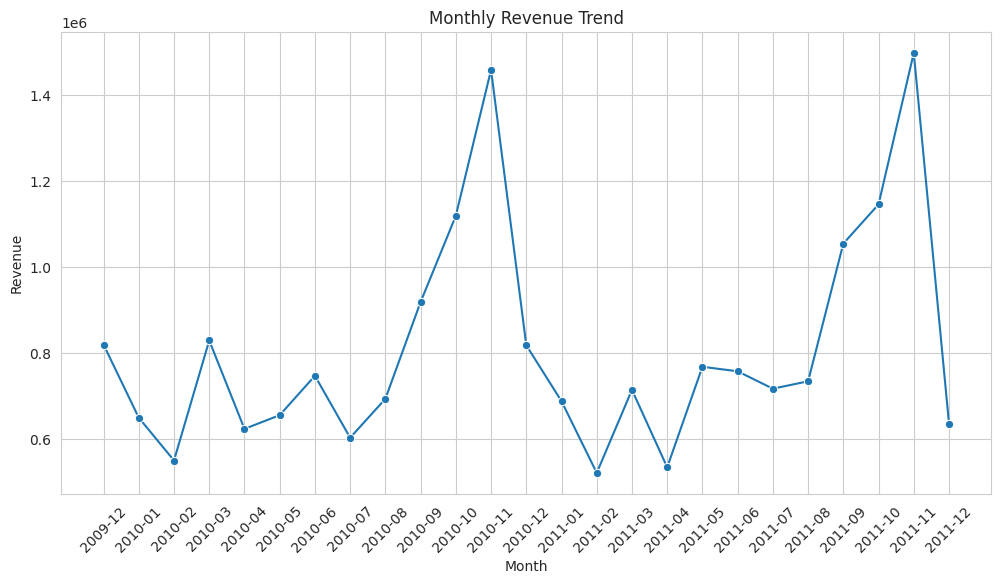

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_revenue,
    x="invoicedate",
    y="net_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [ ]:
country_revenue = revenue.groupby("country")["net_revenue"].sum().reset_index()

country_revenue = country_revenue.sort_values(
    by="net_revenue",
    ascending=False
)

country_revenue.head(10)

,country,net_revenue
38,United Kingdom,14347758.27
2,Bahrain,2935738.74
10,EIRE,617270.89
24,Netherlands,553961.36
14,Germany,424317.06
13,France,349023.48
0,Australia,174422.99
32,Spain,106610.52
34,Switzerland,95035.03
33,Sweden,91515.82


In [ ]:
top_countries = country_revenue.head(5)

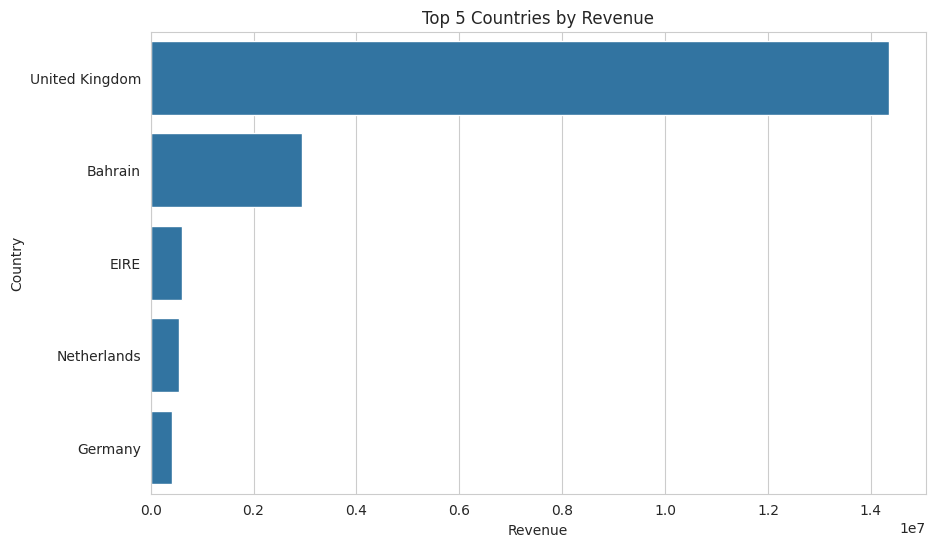

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_countries,
    x="net_revenue",
    y="country"
)

plt.title("Top 5 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

In [ ]:
segment_counts = rfm['segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'customers']

segment_counts

,segment,customers
0,Hibernating,1444
1,Champions,1248
2,Regular,989
3,Big Spenders,870
4,At-Risk,606
5,New / Promising,414
6,Loyal,371


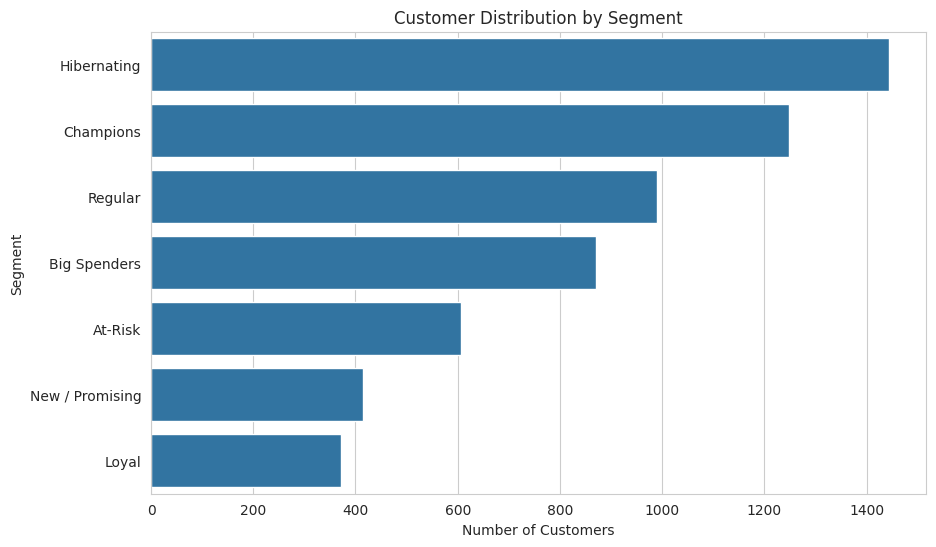

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_counts,
    x="customers",
    y="segment"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

plt.show()

In [ ]:
segment_revenue = rfm.groupby("segment")["monetary"].sum().reset_index()

segment_revenue = segment_revenue.sort_values(
    by="monetary",
    ascending=False
)

segment_revenue

,segment,monetary
2,Champions,11734405.43
1,Big Spenders,3260939.32
0,At-Risk,686058.05
6,Regular,615719.27
4,Loyal,545538.88
3,Hibernating,358574.47
5,New / Promising,127384.38


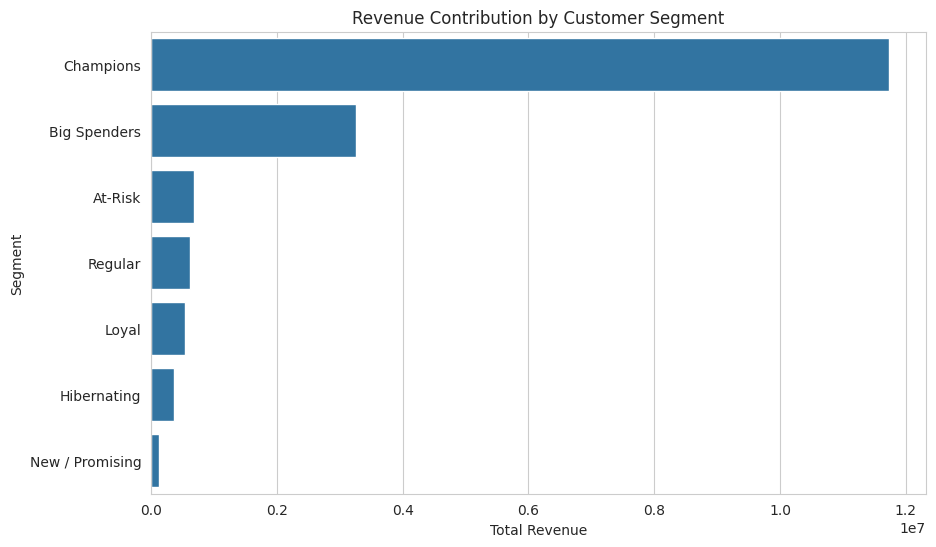

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_revenue,
    x="monetary",
    y="segment"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Segment")

plt.show()

In [ ]:
cohort_pivot = cohort.pivot_table(
    index="cohort_month",
    columns="month",
    values="net_revenue",
    aggfunc="sum"
)

cohort_pivot.head()

month,2009-12-01,2010-01-01,2010-02-01,2010-03-01,2010-04-01,2010-05-01,2010-06-01,2010-07-01,2010-08-01,2010-09-01,...,2011-03-01,2011-04-01,2011-05-01,2011-06-01,2011-07-01,2011-08-01,2011-09-01,2011-10-01,2011-11-01,2011-12-01
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12-01,681292.66,402681.86,304769.15,392549.75,316481.47,317914.45,314094.59,328039.62,341884.57,410033.28,...,266178.38,171442.83,301152.68,293309.19,266717.86,285553.74,394344.36,428105.03,470288.28,166447.46
2010-01-01,NaN,152092.51,37824.22,51211.58,56821.48,54040.01,57031.20,45951.18,45013.50,54802.96,...,43320.28,27823.93,42157.55,32536.89,43212.90,36217.24,52927.48,57957.42,47382.11,7154.20
2010-02-01,NaN,NaN,160976.27,30794.67,52067.19,49250.63,42299.21,37174.65,39220.44,45774.60,...,33762.65,19351.80,37030.76,29892.67,32012.02,23607.35,42305.76,45261.93,34742.29,11139.26
2010-03-01,NaN,NaN,NaN,221087.70,46112.65,49841.17,62184.83,45559.13,51339.97,59913.90,...,40585.73,40112.68,43671.89,30122.75,39324.16,47124.27,44145.04,53946.35,57889.14,15855.06
2010-04-01,NaN,NaN,NaN,NaN,119253.52,17138.29,18444.38,28821.29,20642.20,31200.55,...,16948.48,19248.48,32861.62,14749.83,20086.82,17248.42,17901.62,27914.09,25508.98,4440.80


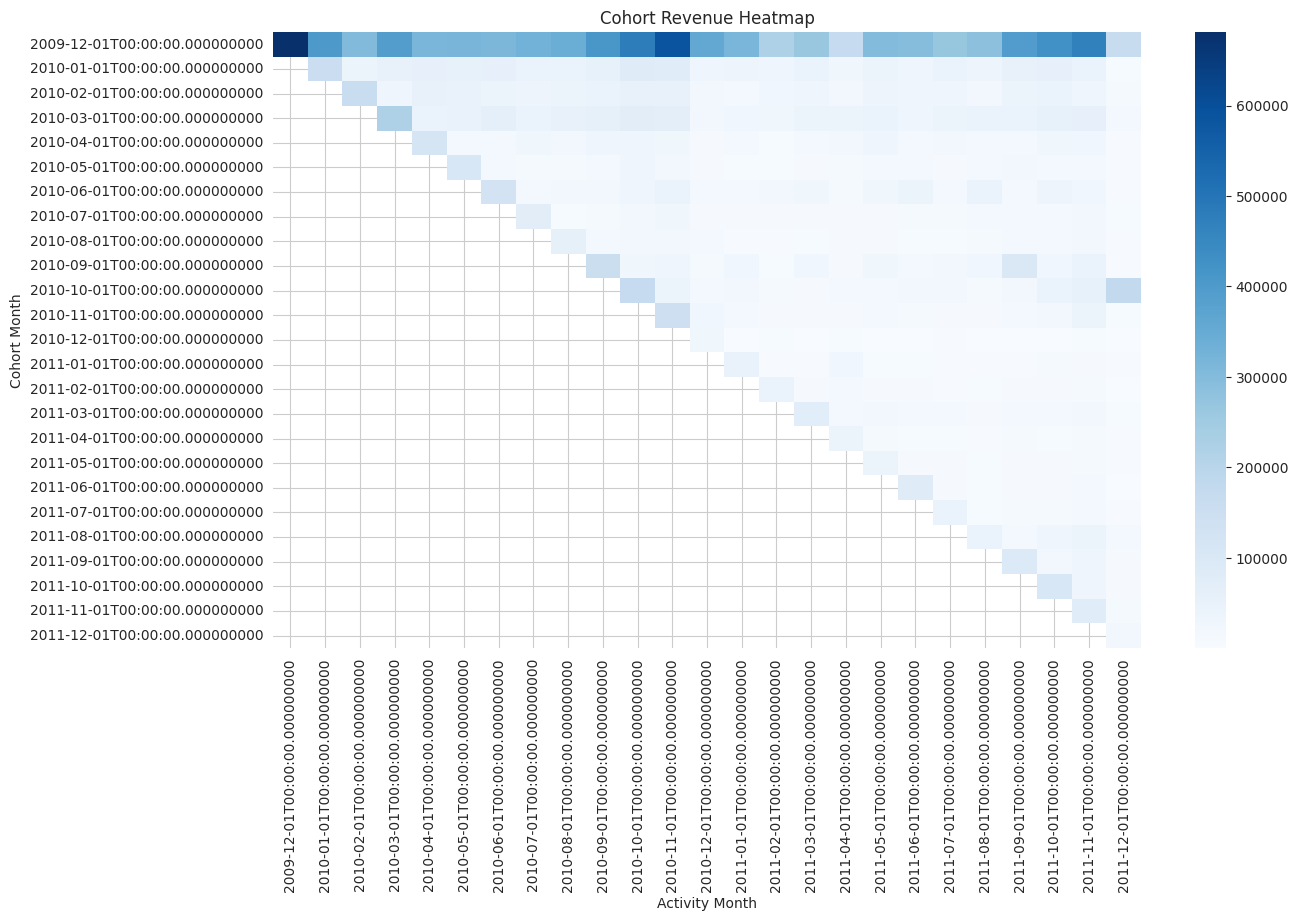

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cohort_pivot,
    cmap="Blues"
)

plt.title("Cohort Revenue Heatmap")
plt.xlabel("Activity Month")
plt.ylabel("Cohort Month")

plt.show()

In [ ]:
# 1. Create the Period (How many months since they started)
# This aligns everyone to 'Month 0' regardless of when they joined
cohort['period'] = (cohort['month'].dt.to_period('M').view(dtype='int64') -
                   cohort['cohort_month'].dt.to_period('M').view(dtype='int64'))

# 2. Pivot using 'period' instead of the actual date
retention_pivot = cohort.pivot_table(
    index="cohort_month",
    columns="period", # Use period here!
    values="customer_id",
    aggfunc="nunique"
)


/tmp/ipykernel_197/2289393470.py:3: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  cohort['period'] = (cohort['month'].dt.to_period('M').view(dtype='int64') -
/tmp/ipykernel_197/2289393470.py:4: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  cohort['cohort_month'].dt.to_period('M').view(dtype='int64'))


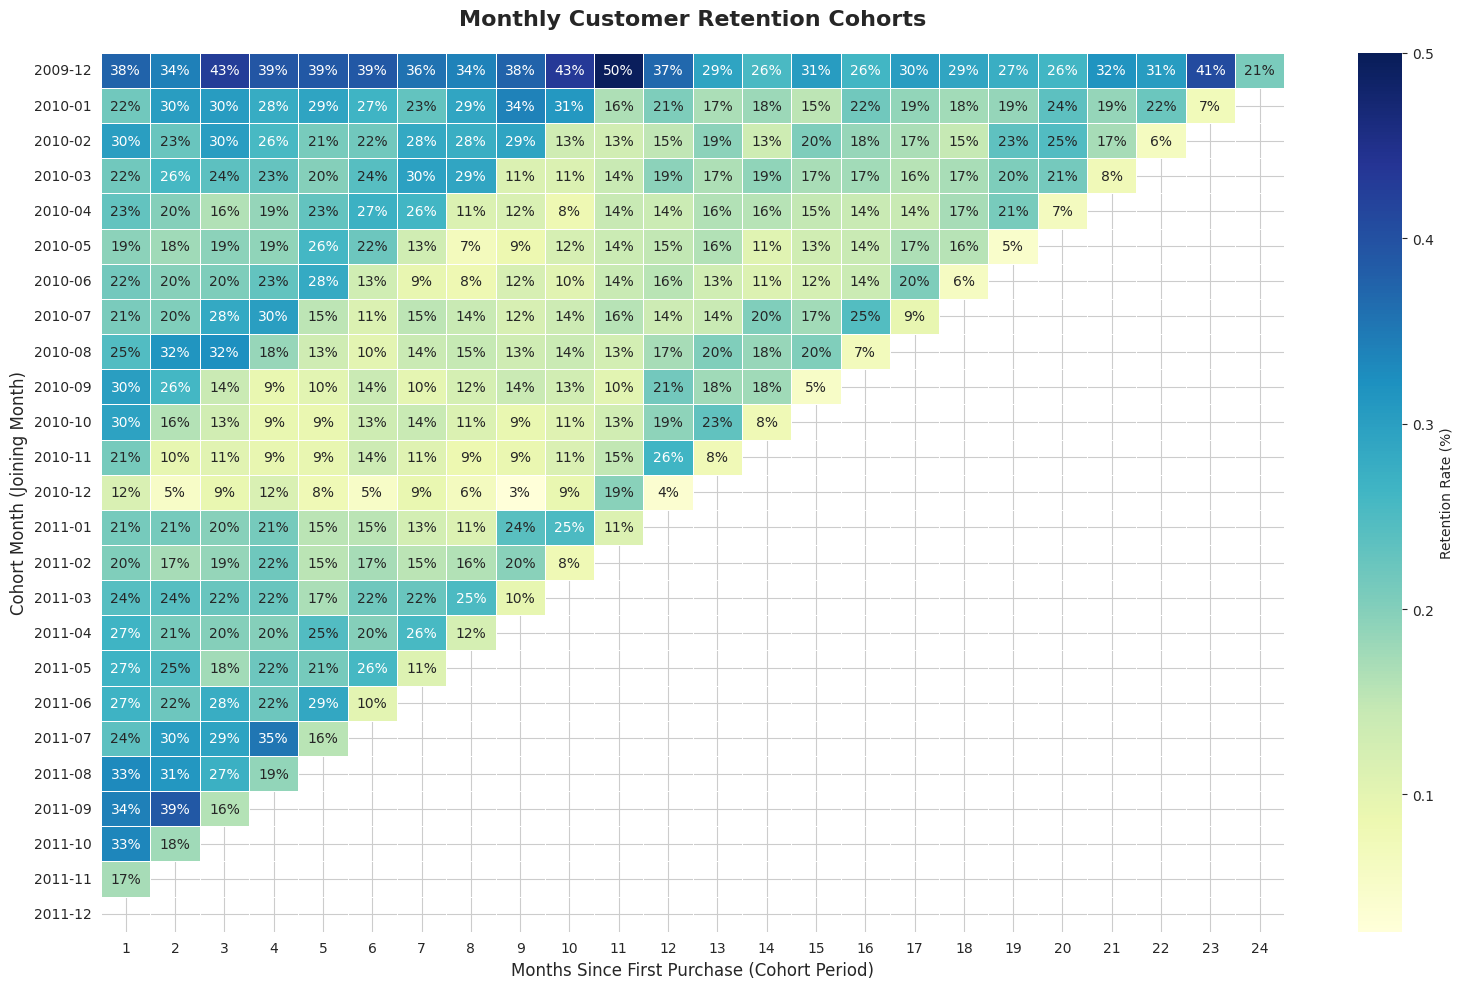

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean up the Index (Date formatting)
retention_rate.index = retention_rate.index.strftime('%Y-%m')

# 2. Setup the Plot
plt.figure(figsize=(16, 10))

# 3. Create a Clean Heatmap
# We use .iloc[:, 1:] to hide 'Month 0' (which is always 100%)
sns.heatmap(
    retention_rate.iloc[:, 1:],
    annot=True,          # Shows the percentages
    fmt='.0%',           # Formats as 20% instead of 0.20
    cmap="YlGnBu",       # Classic professional color scheme
    vmax=0.5,            # Makes 50% the darkest color (makes 20-30% pop)
    linewidths=.5,       # Adds thin white lines between squares for clarity
    cbar_kws={'label': 'Retention Rate (%)'}
)

# 4. Professional Titles
plt.title('Monthly Customer Retention Cohorts', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Months Since First Purchase (Cohort Period)', fontsize=12)
plt.ylabel('Cohort Month (Joining Month)', fontsize=12)

plt.tight_layout()
plt.show()